<a href="https://colab.research.google.com/github/JihoonJung2/undergrad-research-practicum/blob/main/day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install ultralytics --quiet

import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 9.0 MB/s eta 0:00:00
True Tesla T4


In [4]:
from ultralytics import YOLO

# 사전학습된 YOLO 모델 불러오기 (COCO 데이터셋 80개 클래스로 이미 학습된 상태)
model = YOLO('yolo11n.pt')   # n = nano, 가장 가벼운 버전 (빠른 학습/추론용)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [5]:
# COCO128: Ultralytics가 기본 제공하는 128장짜리 작은 데이터셋 (자동 다운로드됨)
results = model.train(
    data='coco128.yaml',   # 데이터셋 설정 파일 (이미지 경로, 클래스 목록 등이 정의돼 있음)
    epochs=20,
    imgsz=640,              # YOLO 기본 입력 크기
    batch=16,
    device=0,                # GPU 사용 (0번 GPU)
    project='runs',          # 결과 저장 폴더
    name='day4_yolo'
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=day4_yolo, nbs=64, nms=None, opset=None, optimize=False, optimi

In [6]:
metrics = model.val()

print(f"mAP@0.5:      {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2059.6±656.7 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 41.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9it/s 2.7s
                   all        128        929      0.808      0.694      0.779      0.594
                person         61        254       0.92       0.63      0.819      0.596
               bicycle          3          6       0.53      0.167      0.341      0.253
                   car         12         46      0.853      0.239      0.388      0.229
            motorcycle          4          5       0.79          1      0.995      0.851
              airplane          5 

In [9]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'yolo11n.pt', 'weights', 'runs', 'datasets', 'sample_data']



image 1/128 /content/datasets/coco128/images/train2017/000000000009.jpg: 480x640 1 fork, 3 bowls, 7 oranges, 1 broccoli, 15.9ms
image 2/128 /content/datasets/coco128/images/train2017/000000000025.jpg: 448x640 1 giraffe, 81.5ms
image 3/128 /content/datasets/coco128/images/train2017/000000000030.jpg: 448x640 1 potted plant, 1 vase, 13.3ms
image 4/128 /content/datasets/coco128/images/train2017/000000000034.jpg: 448x640 1 zebra, 13.3ms
image 5/128 /content/datasets/coco128/images/train2017/000000000036.jpg: 640x512 1 person, 1 umbrella, 90.6ms
image 6/128 /content/datasets/coco128/images/train2017/000000000042.jpg: 480x640 1 dog, 15.4ms
image 7/128 /content/datasets/coco128/images/train2017/000000000049.jpg: 640x512 5 persons, 3 horses, 1 potted plant, 36.5ms
image 8/128 /content/datasets/coco128/images/train2017/000000000061.jpg: 512x640 2 persons, 2 elephants, 408.5ms
image 9/128 /content/datasets/coco128/images/train2017/000000000064.jpg: 640x480 1 car, 2 trucks, 1 stop sign, 1 clock, 

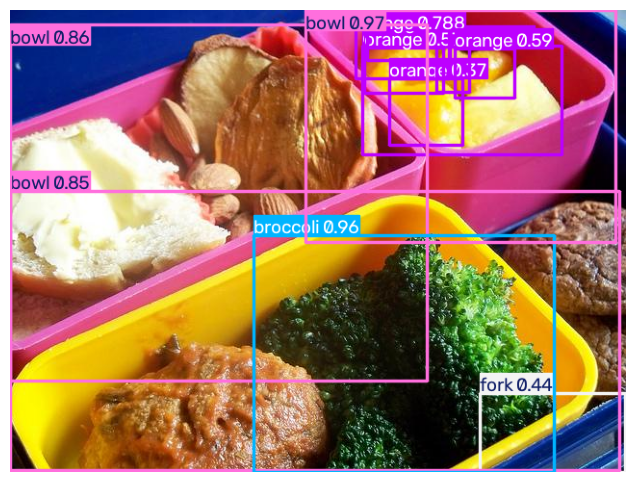

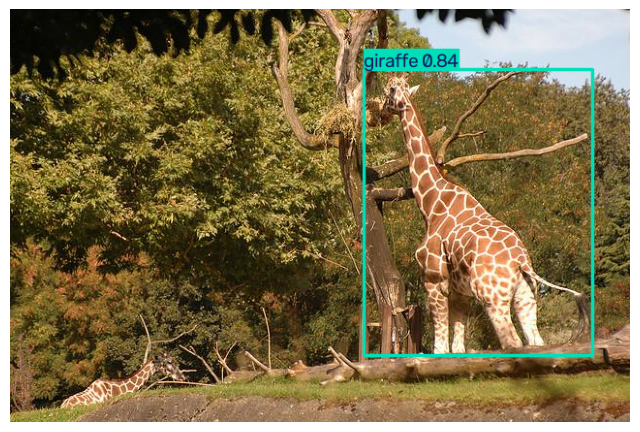

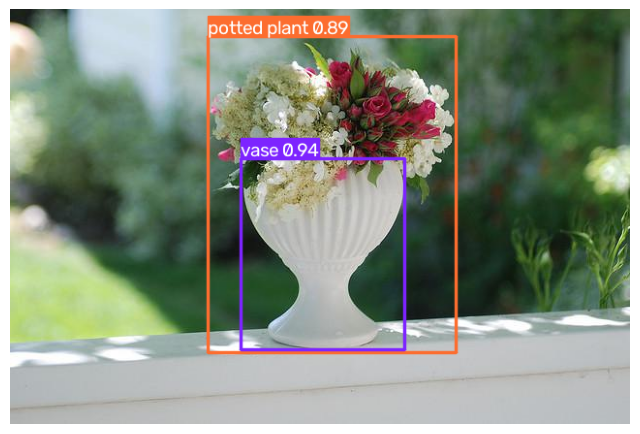

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# 학습에 쓴 데이터셋 중 샘플 이미지로 예측 테스트
results = model.predict(source='datasets/coco128/images/train2017', save=False, conf=0.25)

# 처음 3장만 시각화
for i, r in enumerate(results[:3]):
    im_array = r.plot()   # 예측된 박스가 그려진 이미지 배열
    plt.figure(figsize=(8,6))
    plt.imshow(im_array[..., ::-1])   # BGR → RGB 순서 변환
    plt.axis('off')
    plt.show()